# Exercise 03: Fitting and Forecasting AR Models

**CBIOMES Workshop · Time Series in R**

In this notebook, you will:

1. Fit **AR(1)** and higher-order **AR(p)** models to ecological data.
2. Diagnose model adequacy with **residuals** and the **Ljung–Box test**.
3. Compare models using **one-step-ahead** rolling forecasts and **multi-step** forecasts.

## Setup

In the workshop **Docker container** all packages are pre-installed.

Expected file: `NPZ_Narragansett_Example.csv` (columns `time, NO3, P, Z`).

---

## Part 1: Data exploration

We focus on zooplankton concentration `Z`. Run the following code to load the data.

### Hints

- `read.csv()` returns a matrix; wrap with `as.data.frame()` for classic indexing for now we will assume that the data is measured in a regular interval.
- `npz$Z` extracts the zooplankton series.

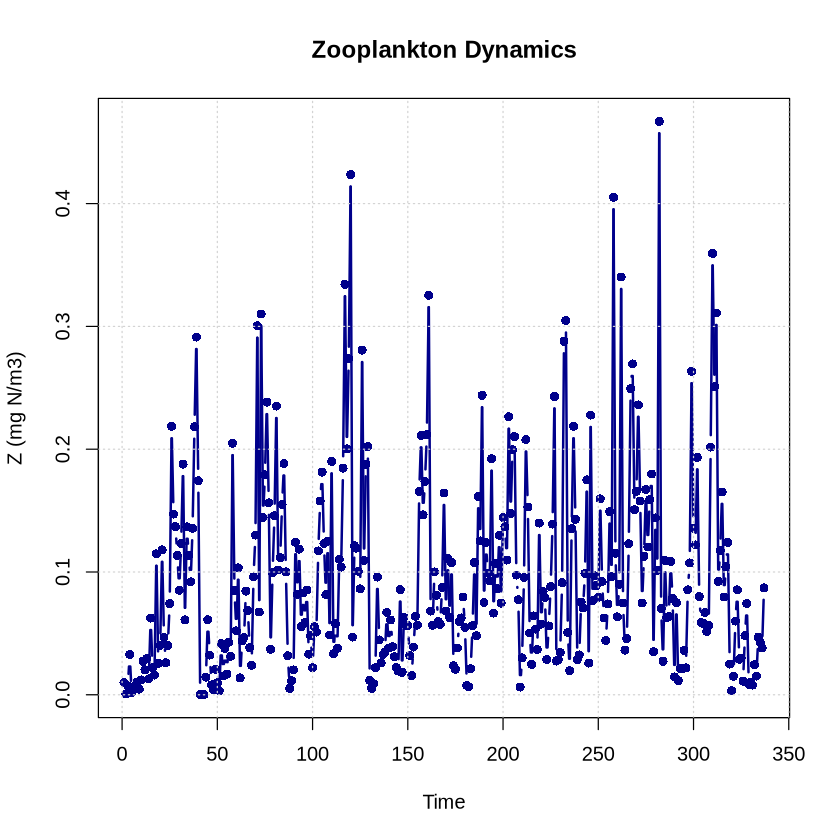

In [1]:
npz  <- as.data.frame(read.csv("NPZ_Narragansett_Example.csv"))
z    <- npz$Z
time <- seq_along(z)

plot(time, z, type = "b", pch = 16, col = "darkblue", lwd = 2,
     xlab = "Time", ylab = "Z (mg N/m3)",
     main = "Zooplankton Dynamics")
grid()

**Discuss:** Trends? Cycles? Outliers?

---

## Part 2: AR(1) model fitting

We fit an autoregressive model of order 1:

$$ y_t = \phi\,y_{t-1} + \varepsilon_t $$

The R function `ar()` does the work. With `method = "ols"` it uses ordinary least squares; `aic = FALSE` and `order.max = 1` force AR(1).

### Hints

- `fit_ar1$ar` is the estimated $\phi$.
- `fit_ar1$resid` are the residuals (with `NA`s at the start for the lags).
- `Box.test(..., type = "Ljung-Box")` tests whether the residuals are white noise. `p > 0.05` ⇒ we **fail to reject** "residuals are white noise", that's good.

In [2]:
fit_ar1 <- ar(z, method = "ols", order.max = 1, aic = FALSE)
fit_ar1

p   <- fit_ar1$order
phi <- fit_ar1$ar


Call:
ar(x = z, aic = FALSE, order.max = 1, method = "ols")

Coefficients:
     1  
0.4218  

Intercept: 0.0002427 (0.003986) 

Order selected 1  sigma^2 estimated as  0.005339

Run the following code to get a estimated fit.

In [3]:
# Compute fitted values manually: y_hat[t] = phi * y[t-1]
y_hat <- rep(NA, length(z))
for (t in (p + 1):length(z)) {
    y_hat[t] <- sum(phi * z[(t - 1):(t - p)])
}

Run the following code to plot the obsered data and the fitted AR(1) model.

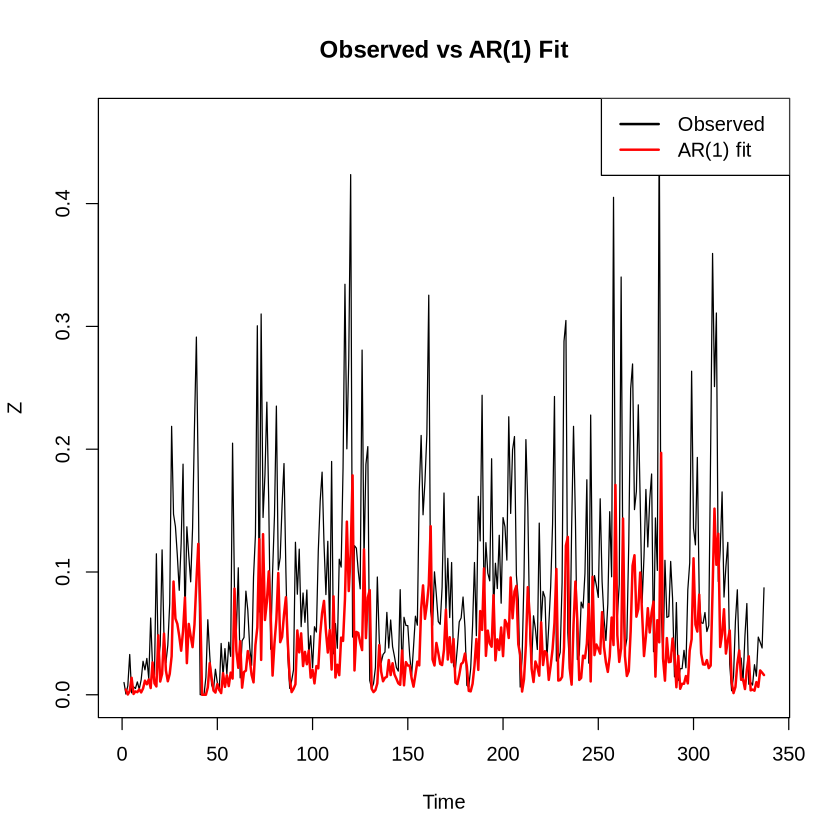

In [4]:
plot(z, type = "l", col = "black",
     main = "Observed vs AR(1) Fit",
     xlab = "Time", ylab = "Z")
lines(y_hat, col = "red", lwd = 2)
legend("topright",
       legend = c("Observed", "AR(1) fit"),
       col = c("black", "red"),
       lty = 1, lwd = 2)

Check the residuals (error) of the model using the $resid of the fitted model fit_ar1 by plotting the residuals with plot().

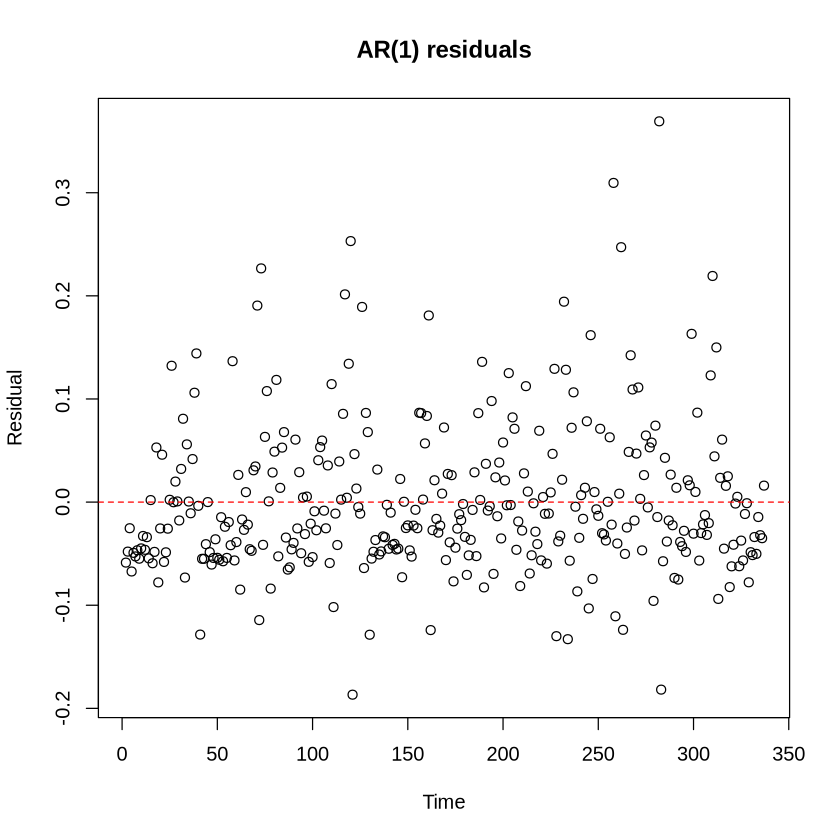

In [5]:
plot(fit_ar1$resid, type = "p", main = "AR(1) residuals",
     xlab = "Time", ylab = "Residual")
abline(h = 0, col = "red", lty = 2)

Apply the Box.test(___, lag = 20, type = "Ljung-Box") test on the residuals.

In [6]:
Box.test(fit_ar1$resid, lag = 20, type = "Ljung-Box")


	Box-Ljung test

data:  fit_ar1$resid
X-squared = 23.898, df = 20, p-value = 0.2469


**Reading the result.** The Ljung-Box `p`-value is well above 0.05 → we cannot reject the null of independent residuals → AR(1) does a reasonable job.

### Discussion

- How well does AR(1) capture the dynamics?
- What patterns remain in the residuals?

---

## Part 3: AR(p) comparison

Now let `ar()` choose the best `p` up to 7 by AIC. Check how many lags are selected and what the coefficients are. 

### Hints

- `aic = TRUE` lets `ar()` pick the order; `order.max = 7` is the upper limit.

In [7]:
fit_arp <- ar(z, method = "ols", order.max = 7, aic = TRUE)
fit_arp


Call:
ar(x = z, aic = TRUE, order.max = 7, method = "ols")

Coefficients:
     1       2  
0.3677  0.1226  

Intercept: 0.0004092 (0.003964) 

Order selected 2  sigma^2 estimated as  0.005264

In [8]:
cat("Selected p:", fit_arp$order, "\n")
cat("Coefficients:\n")
print(fit_arp$ar)

Selected p: 2 
Coefficients:
, , 1

          [,1]
[1,] 0.3676636
[2,] 0.1226159



Run the following code to get a better understanding of the autocorrelation structure of the residuals.

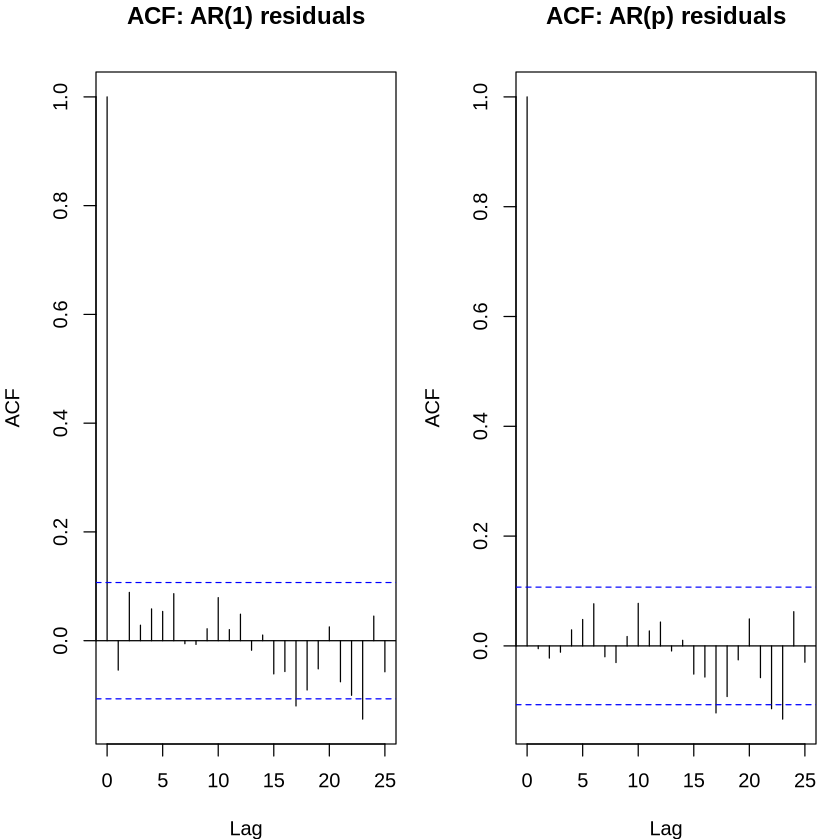

In [9]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(na.omit(fit_ar1$resid), main = "ACF: AR(1) residuals")
acf(na.omit(fit_arp$resid), main = "ACF: AR(p) residuals")
par(mfrow = c(1, 1))

Run the following code to get a goodness of fit measure in terms of mean squared error (MSE).

In [10]:
mse_ar1 <- mean(na.omit(fit_ar1$resid)^2)
mse_arp <- mean(na.omit(fit_arp$resid)^2)
c(MSE_AR1 = round(mse_ar1, 5), MSE_ARp = round(mse_arp, 5))

MSE_AR1 MSE_ARp 
0.00534 0.00526

**Reading the result.** A higher-order model often *cleans* the residual ACF a bit, but the in-sample MSE is only marginally lower. This is a first taste of the trade-off between **goodness of fit** and **parsimony**.

---

## Part 4: Forecasting performance

### 4.1 Train/test split and one-step-ahead rolling forecasts

We hold out 30% of the data as a test set and forecast it one step at a time, refitting the model after each new observation. This mirrors how forecasting works in practice.

### Hints

- `predict(fit, n.ahead = 1)$pred` gives the next forecast.
- For a rolling forecast we keep extending the history with the **observed** test value (not the forecast).

In [11]:
# Usually, we take something from 2/3 to 8/10 from the total proportion as training data
y <- z
T_full <- length(y)
train_size <- floor(0.7 * T_full)

# Split the data
y_train <- y[1:train_size]
y_test  <- y[(train_size + 1):T_full]


# Rolling 1-step-ahead forecaster
# Start with the train data and then pretend that you see one more data point each time from the test data.
one_step_forecast <- function(y_train, y_test, max_lag = 1) {
    history <- y_train
    preds   <- numeric(length(y_test))
    for (i in seq_along(y_test)) {
        fit <- ar(history, method = "ols",
                  order.max = max_lag, aic = FALSE)
        preds[i] <- predict(fit, n.ahead = 1)$pred
        history  <- c(history, y_test[i])   # extend with observed value
    }
    preds
}

# Predict
pred_ar1_1step <- one_step_forecast(y_train, y_test, max_lag = 1)
pred_arp_1step <- one_step_forecast(y_train, y_test, max_lag = 7)


# Print the predicted forecast
mse_ar1_1step <- mean((y_test - pred_ar1_1step)^2)
mse_arp_1step <- mean((y_test - pred_arp_1step)^2)
c(MSE_AR1_1step = round(mse_ar1_1step, 5),
  MSE_ARp_1step = round(mse_arp_1step, 5))

MSE_AR1_1step MSE_ARp_1step 
      0.00733       0.00756

The MSE is better for the simpler model.

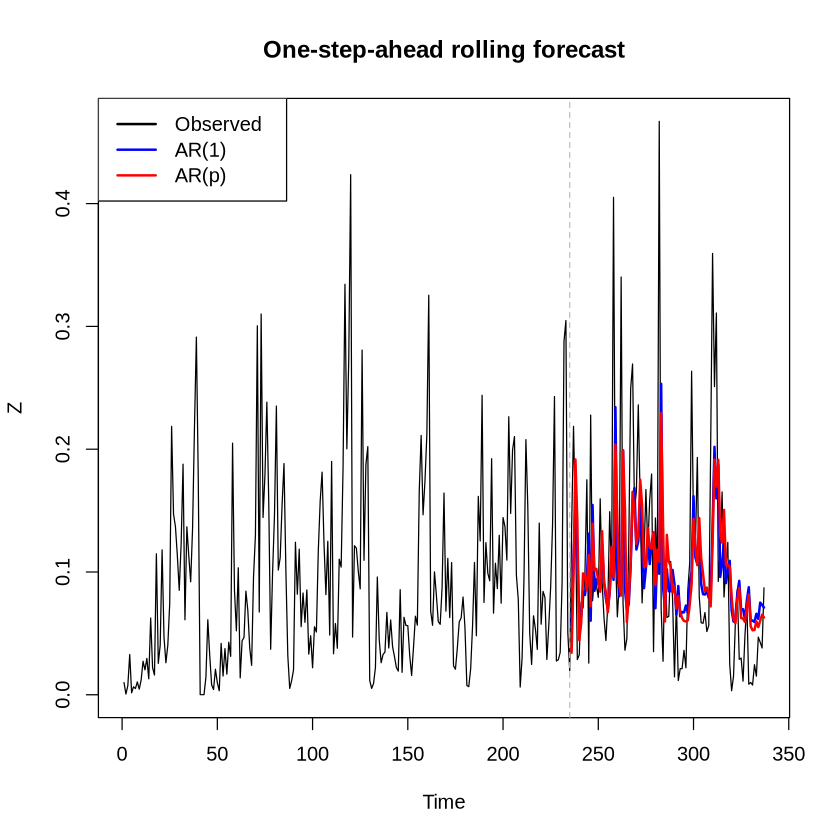

In [12]:
plot(y, type = "l",
     main = "One-step-ahead rolling forecast",
     xlab = "Time", ylab = "Z")
abline(v = train_size, lty = 2, col = "grey")
lines((train_size + 1):T_full, pred_ar1_1step, col = "blue", lwd = 2)
lines((train_size + 1):T_full, pred_arp_1step, col = "red",  lwd = 2)
legend("topleft",
       legend = c("Observed", "AR(1)", "AR(p)"),
       col = c("black", "blue", "red"),
       lty = 1, lwd = 2)

### (Optional) 4.2 Multi-step forecasts (h = 10)

In [13]:
h <- 10
fit_ar1_train <- ar(y_train, method = "ols", order.max = 1, aic = FALSE)
fit_arp_train <- ar(y_train, method = "ols", order.max = 7, aic = TRUE)

fc_ar1 <- predict(fit_ar1_train, n.ahead = h)$pred
fc_arp <- predict(fit_arp_train, n.ahead = h)$pred

mse_ar1_h <- mean((y_test[1:h] - fc_ar1)^2)
mse_arp_h <- mean((y_test[1:h] - fc_arp)^2)
c(MSE_AR1_h = mse_ar1_h, MSE_ARp_h = mse_arp_h)

MSE_AR1_h   MSE_ARp_h 
0.004921265 0.005120947

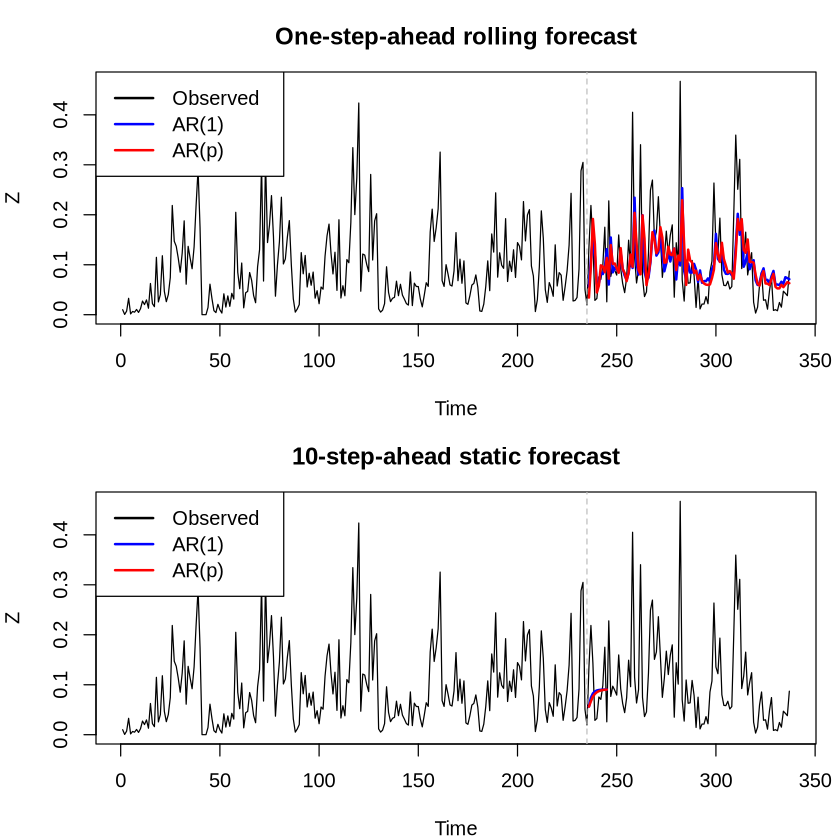

In [14]:
par(mfrow = c(2, 1), mar = c(4, 4, 3, 1))

plot(y, type = "l",
     main = "One-step-ahead rolling forecast",
     xlab = "Time", ylab = "Z")
abline(v = train_size, lty = 2, col = "grey")
lines((train_size + 1):T_full, pred_ar1_1step, col = "blue", lwd = 2)
lines((train_size + 1):T_full, pred_arp_1step, col = "red",  lwd = 2)
legend("topleft",
       legend = c("Observed", "AR(1)", "AR(p)"),
       col = c("black", "blue", "red"),
       lty = 1, lwd = 2)

plot(y, type = "l",
     main = paste0(h, "-step-ahead static forecast"),
     xlab = "Time", ylab = "Z")
abline(v = train_size, lty = 2, col = "grey")
idx <- (train_size + 1):(train_size + h)
lines(idx, fc_ar1, col = "blue", lwd = 2)
lines(idx, fc_arp, col = "red",  lwd = 2)
legend("topleft",
       legend = c("Observed", "AR(1)", "AR(p)"),
       col = c("black", "blue", "red"),
       lty = 1, lwd = 2)

par(mfrow = c(1, 1))

### Discussion

- Which model performs better for short-term forecasting? Why?
- How does forecast uncertainty grow with horizon?
- Why does multi-step forecast often converge to the mean? (Stationary AR processes mean-revert.)
- **The big question:** in-sample fit vs. out-of-sample forecast accuracy, when do they disagree?


---

## Wrap-up

- Fit AR(1) and AR(p) with `ar()`.
- Diagnose with **residuals** and the **Ljung-Box** test.
- Compare models with **rolling** and **static** out-of-sample forecasts.

## Where this fits in the workflow

```
... Plot, ACF/PACF, spectrum, stationarity ...
       ↓
[Fit & forecast AR models]   ← you are here
       ↓
Choose lag order p systematically (Exercise 04)
       ↓
Make sure the data is actually stationary first! (Exercise 05)
       ↓
Multivariate models (Exercises 06, 08, 09, 10)
```

Next: how to choose `p` more systematically with **information criteria** (Exercise 04).